# Validation of glow2 / glow_waveforms.glow_bilby against previous studies
This is a glow2 port of `notebooks/validations_comparisons.ipynb`, which used GLoW v1. It reproduces the published
figures, and the F(w) curves are computed with `glow_waveforms.amplification`, the same code the waveforms use.
It uses only glow2; there are no GLoW v1 inputs.

The notebook checks the following:

1. **Published figures**: Gravelamps fig 1, GLWORIA fig 3 (NFW, CIS), and Mishra et al figs 1-2. Compare these
   visually with the papers.
2. **Closed forms**: the numerical path the waveforms use, compared with glow2's analytic `Fw_PL` (point lens)
   and `Fw_SIS`.
3. **Geometric-optics limit**: for lenses without a closed form (NFW, CIS, PL + shear), F(w) should approach the
   geometric-optics sum over images, `Fw.eval_GO`, at $w \gg 1$. The images and magnifications come from the lens
   equation, independently of the time-domain integral and its Fourier transform.
4. **Shear-model convention**: the package `PLshear` parametrisation (lens-plane offset) against an independent
   set-up with the lens at the origin and the source displaced.

glow_waveforms.glow_bilby multiplies the waveform by $F^*(w)$, as glowpe did. The curves below are $F(w)$, i.e. not conjugated.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from glow2 import lenses, freq_domain, images, time_domain
from glow_waveforms.amplification import get_Fw, get_Fw_sym, GMsun8pi
from glow_waveforms.glow_bilby.source import (_LENS_BUILDERS, lens_offset_from_source_position,
                               source_position_from_lens_offset)

summary = []

def rel_diff(F, F_ref):
    return np.abs(F - F_ref) / np.abs(F_ref)

def record(case, F, F_ref, mask=None):
    r = rel_diff(F, F_ref) if mask is None else rel_diff(F, F_ref)[mask]
    summary.append((case, np.median(r), np.percentile(r, 99), np.max(r)))

def Fw_sym(Psi, y, w, debug=False):
    """ glow2 F(w) (not conjugated) for axisymmetric lenses, as in the waveforms. """
    It, Fws = get_Fw_sym(Psi, y, w, debug=True)
    Fws = None if Fws is None else np.conj(Fws)
    return (It, Fws) if debug else Fws

def Fw_GO(It, w):
    """ Geometric-optics limit from the same images (independent of I(tau) and the FT). """
    return freq_domain.Fw_MixedFT(It, {'wmin': w[0], 'wmax': w[-1]}).eval_GO(w)

## Reproduce [Gravelamps (fig 1)](https://arxiv.org/pdf/2112.07012)
NFW: $k_s = \psi_0 = 2$, $x_s = 1$. Lower panels: PL against the analytic `Fw_PL` and SIS against `Fw_SIS`,
both solid. Dotted lines are the difference from the geometric-optics limit (NFW, and also PL/SIS), which should
fall off towards $w \gg 1$.

glow2's numerical path fails at **exactly** $y=1$ for the SIS (the caustic where the second image vanishes),
and the 2d fallback fails too. This has zero measure in PE (the likelihood is set to $-\infty$ there), and
$y=1\pm10^{-4}$ works. For that curve the analytic glow2 `Fw_SIS` is used.

         for t=12.6228 and bracket (3.31258e-06, 3.31258e-06) [init_glow_Brackets:235]
         for t=15.5587 and bracket (1.75833e-07, 1.75834e-07) [init_glow_Brackets:235]
         for t=19.2 and bracket (5.6177e-09, 5.79408e-09) [init_glow_Brackets:235]
         for t=11.3755 and bracket (1.15303e-05, 1.15304e-05) [init_glow_Brackets:235]
         for t=14.0118 and bracket (8.25884e-07, 8.25885e-07) [init_glow_Brackets:235]
         for t=17.2815 and bracket (3.07472e-08, 3.12134e-08) [init_glow_Brackets:235]
         for t=21.3366 and bracket (4.60206e-09, 4.75423e-09) [init_glow_Brackets:235]
         for t=11.5979 and bracket (9.60811e-06, 9.60816e-06) [init_glow_Brackets:235]
         for t=14.3667 and bracket (6.0276e-07, 6.02945e-07) [init_glow_Brackets:235]
         for t=17.8095 and bracket (1.98106e-08, 2.02826e-08) [init_glow_Brackets:235]
         for t=22.0901 and bracket (2.41562e-09, 2.71837e-09) [init_glow_Brackets:235]
         for t=12.907 and bracket (2.59479e-06, 

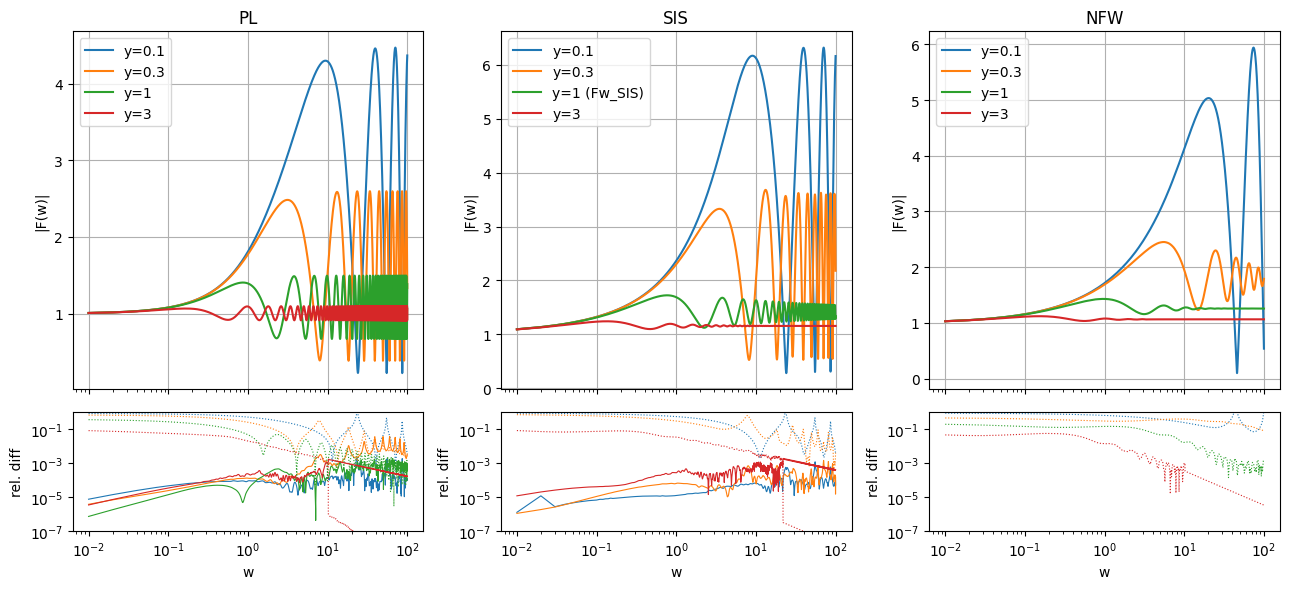

In [3]:
ws = np.linspace(1e-2, 1e2, 10000)
analytic = {'PL': freq_domain.Fw_PL, 'SIS': freq_domain.Fw_SIS}
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
for i, name in enumerate(['PL', 'SIS', 'NFW']):
    for j, y in enumerate([0.1, 0.3, 1, 3]):
        c = 'C%d' % j
        Psi = {'PL': lenses.Psi_PL({}), 'SIS': lenses.Psi_SIS({}),
               'NFW': lenses.Psi_NFW({'psi0': 2, 'xs': 1})}[name]
        It, F = Fw_sym(Psi, y, ws, debug=True)
        label = 'y={}'.format(y)
        if F is None:
            F, label = analytic[name](y)(ws), label + ' (Fw_SIS)'
        axes[0, i].semilogx(ws, np.abs(F), c=c, label=label)
        if name in analytic and not label.endswith('(Fw_SIS)'):
            Fa = analytic[name](y)(ws)
            axes[1, i].loglog(ws, rel_diff(F, Fa), c=c, lw=0.8)
            record('Gravelamps {} y={} vs analytic {}'.format(name, y, 'Fw_' + name), F, Fa)
        if It is not None and not label.endswith('(Fw_SIS)'):
            Fgo = Fw_GO(It, ws)
            axes[1, i].loglog(ws, rel_diff(F, Fgo), ':', c=c, lw=0.8)
            record('Gravelamps {} y={} vs GO (w>50)'.format(name, y), F, Fgo, ws > 50)
    axes[0, i].set_title(name)
    axes[0, i].set_ylabel('|F(w)|'); axes[0, i].legend(); axes[0, i].grid()
    axes[1, i].set_xlabel('w'); axes[1, i].set_ylabel('rel. diff'); axes[1, i].set_ylim(1e-7, 1)
fig.tight_layout()
plt.show()

## Reproduce [GLWORIA NFW & CIS waveforms (fig 3)](https://arxiv.org/pdf/2403.13876)
For the parameter conversion, see eqs. 26-28 of the paper: $\psi_0 = \kappa$, $x_s = 1$. Dashed lines show the
geometric-optics limit, and the lower panels show the difference from it.

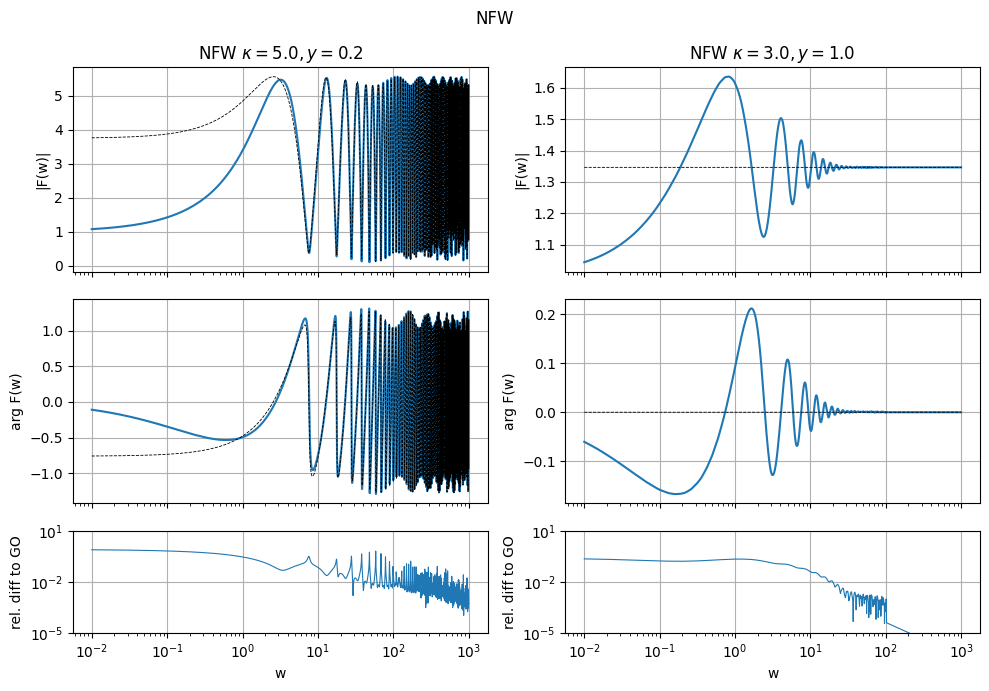

In [4]:
w_g = np.logspace(-2, 3, 5000)

def plot_abs_arg_go(cases, suptitle):
    fig, axes = plt.subplots(3, len(cases), figsize=(5 * len(cases), 7), sharex=True,
                             gridspec_kw={'height_ratios': [2, 2, 1]})
    for i, (title, F, Fgo) in enumerate(cases):
        axes[0, i].semilogx(w_g, np.abs(F)); axes[0, i].semilogx(w_g, np.abs(Fgo), 'k--', lw=0.6)
        axes[1, i].semilogx(w_g, np.angle(F)); axes[1, i].semilogx(w_g, np.angle(Fgo), 'k--', lw=0.6)
        axes[2, i].loglog(w_g, rel_diff(F, Fgo), lw=0.8)
        axes[0, i].set_title(title); axes[0, i].set_ylabel('|F(w)|'); axes[1, i].set_ylabel('arg F(w)')
        axes[2, i].set_ylabel('rel. diff to GO'); axes[2, i].set_xlabel('w'); axes[2, i].set_ylim(1e-5, 10)
        for a in axes[:, i]: a.grid()
    fig.suptitle(suptitle); fig.tight_layout()
    plt.show()

cases = []
for psi0, y in [(5, 0.2), (3, 1)]:
    It, F = Fw_sym(lenses.Psi_NFW({'psi0': psi0, 'xs': 1}), y, w_g, debug=True)
    Fgo = Fw_GO(It, w_g)
    cases.append(('NFW $\\kappa = %.1f, y = %.1f$' % (psi0, y), F, Fgo))
    record('GLWORIA NFW psi0={} y={} vs GO (w>100)'.format(psi0, y), F, Fgo, w_g > 100)
plot_abs_arg_go(cases, 'NFW')

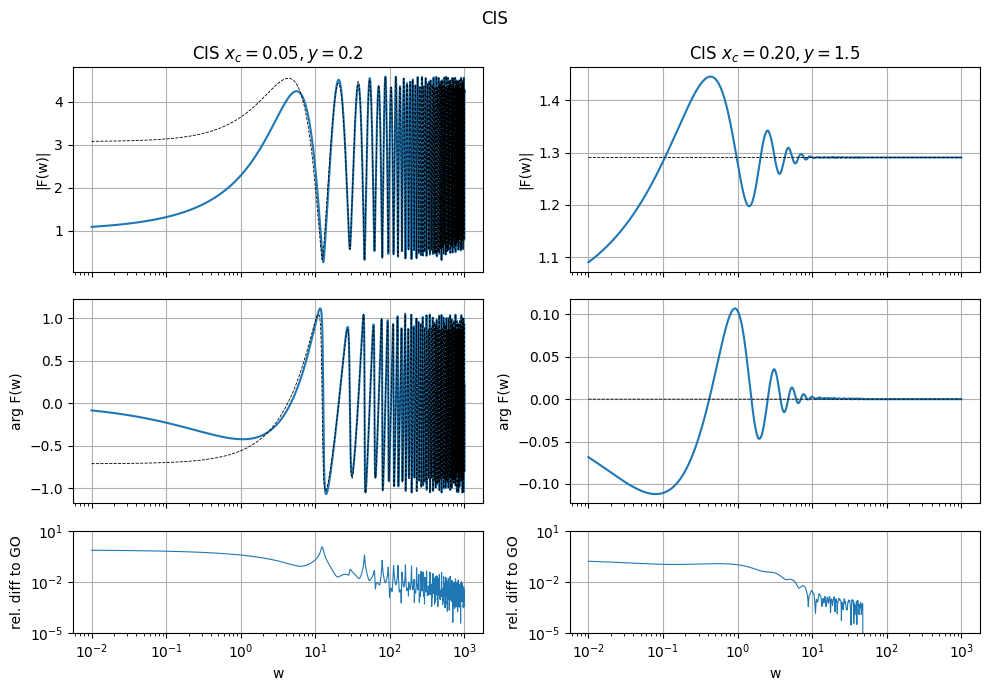

In [5]:
cases = []
for rc, y in [(0.05, 0.2), (0.2, 1.5)]:   # (the v1 notebook looped over range(len(psi0)))
    It, F = Fw_sym(lenses.Psi_CIS({'rc': rc}), y, w_g, debug=True)
    Fgo = Fw_GO(It, w_g)
    cases.append(('CIS $x_c = %.2f, y = %.1f$' % (rc, y), F, Fgo))
    record('GLWORIA CIS rc={} y={} vs GO (w>100)'.format(rc, y), F, Fgo, w_g > 100)
plot_abs_arg_go(cases, 'CIS')

# Reproduce Mishra et al
### Fig 1: Point lens, $M_{Lz} = 150\,M_\odot$
The waveforms use the analytic `Fw_PL` (solid). Dashed lines are the numerical `Psi_PL` result, and the lower
panels show the difference between the two.

         for t=10.9782 and bracket (1.70712e-05, 1.70712e-05) [init_glow_Brackets:235]
         for t=13.871 and bracket (9.46022e-07, 9.46022e-07) [init_glow_Brackets:235]
         for t=17.5619 and bracket (2.43367e-08, 2.43647e-08) [init_glow_Brackets:235]
         for t=22.2707 and bracket (3.3614e-09, 3.37716e-09) [init_glow_Brackets:235]
         for t=9.77548 and bracket (5.6831e-05, 5.68311e-05) [init_glow_Brackets:235]
         for t=12.3366 and bracket (4.38825e-06, 4.38825e-06) [init_glow_Brackets:235]
         for t=15.6042 and bracket (1.67185e-07, 1.67185e-07) [init_glow_Brackets:235]
         for t=19.7731 and bracket (7.02931e-09, 7.04885e-09) [init_glow_Brackets:235]
         for t=10.9782 and bracket (1.70712e-05, 1.70712e-05) [init_glow_Brackets:235]
         for t=13.871 and bracket (9.46022e-07, 9.46022e-07) [init_glow_Brackets:235]
         for t=17.5619 and bracket (2.43367e-08, 2.43647e-08) [init_glow_Brackets:235]
         for t=22.2707 and bracket (3.3614e-09,

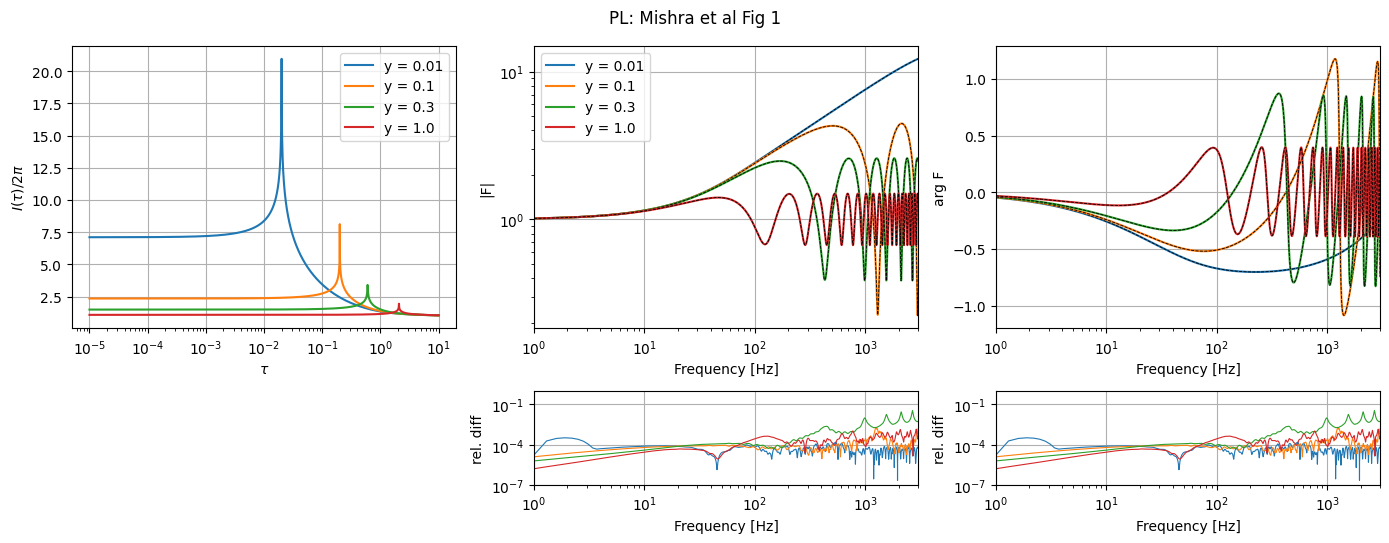

In [6]:
MLz = 150.
f1 = np.linspace(1, 3e3, 10000)
ws = GMsun8pi * MLz * f1
tau = np.logspace(-5, 1, 2000)
fig, axes = plt.subplots(2, 3, figsize=(14, 5.5), gridspec_kw={'height_ratios': [3, 1]})
for j, y in enumerate([0.01, 0.1, 0.3, 1.]):
    c = 'C%d' % j
    It = time_domain.It_Integral1d(images.Images_1d(lenses.Psi_PL({}), y, 0, {}), {})
    F = freq_domain.Fw_PL(y)(ws)
    Fn = Fw_sym(lenses.Psi_PL({}), y, ws)
    record('Mishra fig1 PL y={} numerical vs Fw_PL'.format(y), Fn, F)

    axes[0, 0].plot(tau, It.eval(tau) / 2 / np.pi, c=c, label='y = {}'.format(y))
    axes[0, 1].loglog(f1, np.abs(F), c=c, label='y = {}'.format(y))
    axes[0, 1].loglog(f1, np.abs(Fn), 'k--', lw=0.6)
    axes[0, 2].semilogx(f1, np.angle(F), c=c)
    axes[0, 2].semilogx(f1, np.angle(Fn), 'k--', lw=0.6)
    for k in (1, 2):
        axes[1, k].loglog(f1, rel_diff(Fn, F), c=c, lw=0.8)
axes[0, 0].set(xscale='log', xlabel=r'$\tau$', ylabel=r'$I(\tau)/2\pi$'); axes[0, 0].legend()
axes[0, 1].set(xlabel='Frequency [Hz]', ylabel='|F|', xlim=(1, 3e3)); axes[0, 1].legend()
axes[0, 2].set(xlabel='Frequency [Hz]', ylabel='arg F', xlim=(1, 3e3))
axes[1, 0].axis('off')
for k in (1, 2): axes[1, k].set(xlabel='Frequency [Hz]', ylabel='rel. diff', xlim=(1, 3e3), ylim=(1e-7, 1))
for a in axes.flat: a.grid()
fig.suptitle('PL: Mishra et al Fig 1'); fig.tight_layout()
plt.show()

### Fig 2: PL + shear near a macro-minimum image (type I), source 0.4 from the lens
The original notebook rotated the shear matrix by $-\pi/8$, because GLoW v1 needed $y_2 = 0$. The same set-up is
used here.

**Convention of the package shear models.** `glow_waveforms.glow_bilby` keeps the `glowpe.sources` convention. The source is at
the origin and the lens is displaced to $\mathbf{c} = y(\cos\theta, \sin\theta)$. In glow2 the external
shear/convergence (`Psi_Ext`, and the external field of `Psi_ChangRefsdal`) is centred on the origin, i.e.
on the source. $\mathbf{c}$ is therefore the microlens offset from the unperturbed macro-image **in the lens plane**.
Mishra et al. quote the **source-plane** offset (field centred on the lens),
$\mathbf{u} = -[(1-\kappa)\mathbf{1}-\Gamma]\,\mathbf{c}$ with $|\det| = 1/|\mu|$
(`source_position_from_lens_offset`, inverse `lens_offset_from_source_position`).

Solid lines are the package `PLshear` builder, evaluated at the package parameters that correspond to a source
0.4 from the lens. Dashed black is an independent glow2 set-up: lens at the origin, source at (0.4, 0),
`eval_mode='full'`. Dotted is the geometric-optics limit. Grey is the result of naively plugging $y=0.4$,
$\theta=0$ into the package model, which is a different physical configuration.

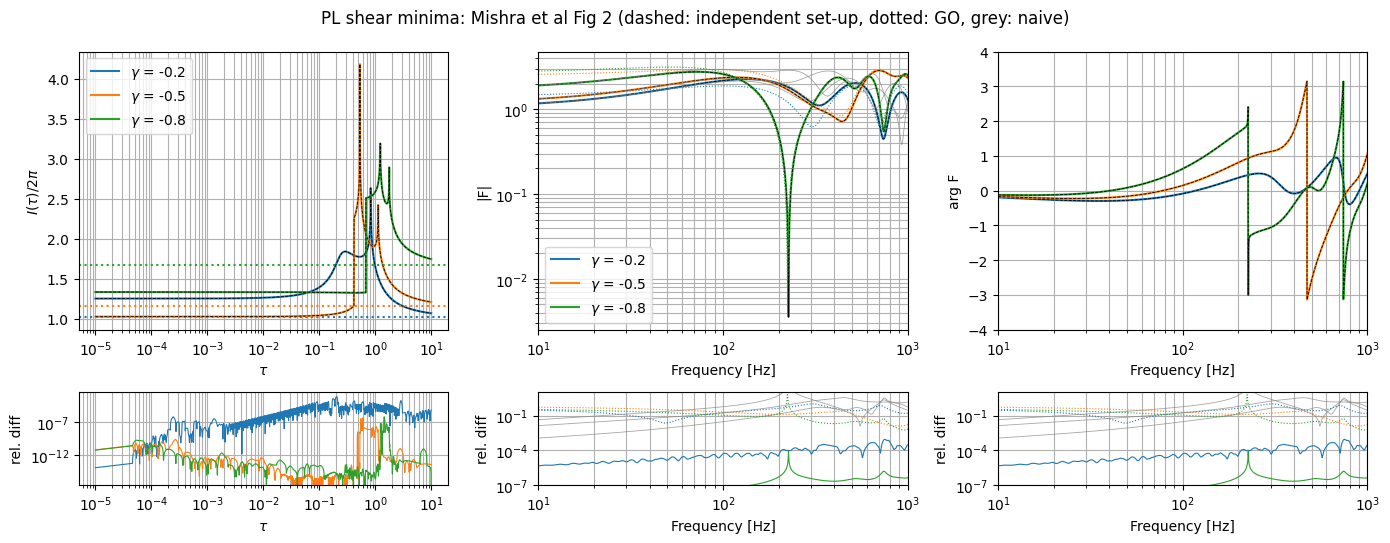

In [7]:
f2 = np.linspace(10, 3e3, 10000)
ws = GMsun8pi * MLz * f2
rot = np.array([[np.cos(-np.pi/8), -np.sin(-np.pi/8)], [np.sin(-np.pi/8), np.cos(-np.pi/8)]])
fig, axes = plt.subplots(2, 3, figsize=(14, 5.5), gridspec_kw={'height_ratios': [3, 1]})
for j, gamma in enumerate([-0.2, -0.5, -0.8]):
    c = 'C%d' % j
    gamma_rot = rot @ np.array([[-gamma, 0], [0, gamma]]) @ rot.T
    g1, g2 = gamma_rot[1, 1], gamma_rot[0, 1]

    # package parametrisation of "source at (0.4, 0) from the lens"
    y_pkg, th_pkg = lens_offset_from_source_position(0.4, 0., g1, g2, 0.)
    Fw_func, Fw_kwargs = _LENS_BUILDERS['PLshear'](psi0=1., y=y_pkg, theta=th_pkg, g1=g1, g2=g2, kp=0.)
    It, Fc = Fw_func(w=ws, debug=True, **Fw_kwargs)
    F = np.conj(Fc)
    # independent set-up: lens (and external field) at the origin, source displaced
    p_phys = {'psi0': 1, 'xc1': 0, 'xc2': 0, 'gamma1': g1, 'gamma2': g2, 'kappa': 0}
    It_ref, Fc_ref = get_Fw(lenses.Psi_ChangRefsdal(p_phys), ws, y1=0.4, y2=0., im_mode='full', debug=True)
    F_ref = np.conj(Fc_ref)
    Fgo = Fw_GO(It_ref, ws)
    # naive: package model with y = 0.4, theta = 0
    Fw_func, Fw_kwargs = _LENS_BUILDERS['PLshear'](psi0=1., y=0.4, theta=0., g1=g1, g2=g2, kp=0.)
    F_naive = np.conj(Fw_func(w=ws, **Fw_kwargs))

    record('Mishra fig2 gamma={} package vs source-displaced set-up'.format(gamma), F, F_ref)
    record('Mishra fig2 gamma={} vs GO (w>30)'.format(gamma), F, Fgo, ws > 30)
    record('Mishra fig2 gamma={} [naive y=0.4, theta=0 in package]'.format(gamma), F_naive, F_ref)

    axes[0, 0].plot(tau, It.eval(tau) / 2 / np.pi, c=c, label='$\\gamma$ = {}'.format(gamma))
    axes[0, 0].plot(tau, It_ref.eval(tau) / 2 / np.pi, 'k--', lw=0.6)
    axes[0, 0].axhline(1 / (1 - gamma**2)**0.5, c=c, ls=':')
    axes[1, 0].loglog(tau, np.abs(It.eval(tau) - It_ref.eval(tau)) / np.abs(It_ref.eval(tau)), c=c, lw=0.8)
    axes[0, 1].loglog(f2, np.abs(F), c=c, label='$\\gamma$ = {}'.format(gamma))
    axes[0, 1].loglog(f2, np.abs(F_ref), 'k--', lw=0.6)
    axes[0, 1].loglog(f2, np.abs(Fgo), ':', c=c, lw=0.8)
    axes[0, 1].loglog(f2, np.abs(F_naive), c='gray', lw=0.6, alpha=0.7)
    axes[0, 2].semilogx(f2, np.angle(F), c=c)
    axes[0, 2].semilogx(f2, np.angle(F_ref), 'k--', lw=0.6)
    for k in (1, 2):
        axes[1, k].loglog(f2, rel_diff(F, F_ref), c=c, lw=0.8)
        axes[1, k].loglog(f2, rel_diff(F, Fgo), ':', c=c, lw=0.8)
        axes[1, k].loglog(f2, rel_diff(F_naive, F_ref), c='gray', lw=0.6, alpha=0.7)
axes[0, 0].set(xscale='log', xlabel=r'$\tau$', ylabel=r'$I(\tau)/2\pi$'); axes[0, 0].legend()
axes[0, 1].set(xlabel='Frequency [Hz]', ylabel='|F|', xlim=(1e1, 1e3)); axes[0, 1].legend()
axes[0, 2].set(xlabel='Frequency [Hz]', ylabel='arg F', xlim=(1e1, 1e3), ylim=(-4, 4))
axes[1, 0].set(xlabel=r'$\tau$', ylabel='rel. diff', xscale='log')
for k in (1, 2): axes[1, k].set(xlabel='Frequency [Hz]', ylabel='rel. diff', xlim=(1e1, 1e3), ylim=(1e-7, 10))
for a in axes.flat: a.grid(which='both')
fig.suptitle('PL shear minima: Mishra et al Fig 2 (dashed: independent set-up, dotted: GO, grey: naive)')
fig.tight_layout()
plt.show()

Package parameters that correspond to the Mishra set-up, and the physical source position that the naive
choice $y=0.4, \theta=0$ actually represents:

In [8]:
for gamma in [-0.2, -0.5, -0.8]:
    gamma_rot = rot @ np.array([[-gamma, 0], [0, gamma]]) @ rot.T
    g1, g2 = gamma_rot[1, 1], gamma_rot[0, 1]
    y_pkg, th_pkg = lens_offset_from_source_position(0.4, 0., g1, g2, 0.)
    y_src, th_src = source_position_from_lens_offset(0.4, 0., g1, g2, 0.)
    print('gamma = {:5.2f}: source (0.4, 0) <-> package (y={:.3f}, theta={:.3f});  '
          'package (0.4, 0) <-> source (y={:.3f}, theta={:.3f})'.format(gamma, y_pkg, th_pkg, y_src, th_src))

gamma = -0.20: source (0.4, 0) <-> package (y=0.363, theta=2.978);  package (0.4, 0) <-> source (y=0.460, theta=-3.018)
gamma = -0.50: source (0.4, 0) <-> package (y=0.393, theta=2.641);  package (0.4, 0) <-> source (y=0.560, theta=-2.886)
gamma = -0.80: source (0.4, 0) <-> package (y=0.792, theta=2.226);  package (0.4, 0) <-> source (y=0.666, theta=-2.795)
